<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Исследование структуры данных

In [2]:
resume_data = pd.read_csv('Data/dst-3.0_16_1_hh_database.csv', sep=';')
display(resume_data.head())

In [4]:
display(resume_data.info())
print(f'Занимаемая память: {round(resume_data.memory_usage(deep=True).sum() / (1024 * 1024))} MB')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

None

Занимаемая память: 531 MB


In [5]:
display(resume_data.describe())

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 1987 Военный инженерный Кра...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


# Преобразование данных

Создадим с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".


In [6]:
def get_education(arg):
    """Функция получения информациии об уровне образования соискателя на основе заданных категорий

    Args:
        arg (object): Информация об образовании и ВУЗе соискателя
    Returns:
        string: Уровень образования
    """
    arg = ' '.join(arg.split(' ')[:2])
    if 'Высшее' in arg:
        return 'высшее'
    elif 'Неоконченное высшее' in arg:
        return 'неоконченное высшее'
    elif 'Среднее специальное' in arg:
        return 'cреднее специальное'
    elif 'Среднее образование' in arg:
        return 'среднее'

resume_data['Образование'] = resume_data['Образование и ВУЗ'].apply(get_education)
resume_data = resume_data.drop('Образование и ВУЗ', axis=1)
print(f"Cредний уровень образования имеет: {resume_data['Образование'].value_counts()['среднее'] } соискателей.") 

Cредний уровень образования имеет: 559 соискателей.


Создадим два новых признака **"Пол"** и **"Возраст"**.

In [7]:
def get_sex(arg):
    """Функция получения информации о поле соискателя

    Args:
        arg (object): Информация о поле и возрасте соискателя

    Returns:
        string: Пол соискателя
    """
    if 'Мужчина' in arg:
        return 'М'
    elif 'Женщина' in arg:
        return 'Ж'
    
def get_age(arg):
    """Функция получения информации о возрасте соискателя

    Args:
        arg (object): Информация о поле и возрасте соискателя

    Returns:
        string: Возраст соискателя
    """
    arg_spitted = arg.split(' ')
    year_words = ['год', 'года', 'лет']
    for index, item in enumerate(arg_spitted):
        if item in year_words:
            return int(arg_spitted[index-1])
    
resume_data['Пол'] = resume_data['Пол, возраст'].apply(get_sex)
resume_data['Возраст'] = resume_data['Пол, возраст'].apply(get_age)
resume_data = resume_data.drop('Пол, возраст', axis=1)
print(f"В данных представлено {round(resume_data['Пол'].value_counts(normalize=True)['Ж']*100,2)} % женских резюме.")
print(f"Средний возраст соискателей равен {round(resume_data['Возраст'].mean(),1)} лет.")

В данных представлено 19.07 % женских резюме.
Средний возраст соискателей равен 32.2 лет.


Получим столбец, содержащий информацию о том, сколько месяцев проработал соискатель.

In [8]:
def get_experience(arg):
    """Функция получения информации об опыте работы соискателя в месяцах

    Args:
        arg (object): Информация об опыте работы соискателя в различных форматах представления

    Returns:
        int: Опыт работы соискателя в месяцах
    """
    if arg is np.nan or arg == 'Не указано':
        return np.nan
    year_words = ['год', 'года', 'лет']
    month_words = ['месяц', 'месяца', 'месяцев']
    arg_splitted = arg.split(' ')[:6]
    months_experience = 0
    for index, item in enumerate(arg_splitted):
        if item in month_words:
            months_experience += int(arg_splitted[index-1])
        elif item in year_words:
            months_experience += int(arg_splitted[index-1]) * 12
    return months_experience       
resume_data['Опыт работы (месяц)'] = resume_data['Опыт работы'].apply(get_experience)
resume_data = resume_data.drop('Опыт работы', axis=1)
print(f"Медианный опыт работы соискателей рвен {resume_data['Опыт работы (месяц)'].median()} месяцев.")

Медианный опыт работы соискателей рвен 100.0 месяцев.


Выполним преобразования признака **"Город, переезд, командировки"** .

In [9]:
def get_city(arg):
    """Функция получения информации о городе проживания соискателя на основе заданных категорий

    Args:
        arg (object): Общая информация по городу проживания соискателя, готовности переезду/командировкам

    Returns:
        string: Город проживания соискателя
    """
    million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород',
                      'Казань', 'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону',
                      'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград' ]
    city = arg.split(' , ')[0]
    if city == 'Москва':
        return city
    elif city == 'Санкт-Петербург':
        return city
    elif city in million_cities:
        return 'город-миллионник'
    else:
        return 'другие'
    
def get_ready_to_move(arg):
    """Функция получения информации о готовности к переезду

    Args:
        arg (object): Общая информация по городу проживания соискателя, готовности переезду/командировкам

    Returns:
        bool: Готовность к перееезду
    """
    if ('не готов к переезду' in arg) or ('не готова к переезду' in arg):
        return False
    elif 'хочу' in arg:
        return True
    else:
        return True
    
def get_ready_for_bisiness_trips(arg):
    """Функция получения информации о готовности к командировкам

    Args:
        arg (object): Общая информация по городу проживания соискателя, готовности переезду/командировкам

    Returns:
        bool: Готовность к командировкам
    """
    if ('командировка' in arg):
        if ('не готов к командировкам' in arg) or('не готова к командировкам' in arg):
            return False
        else: 
            return True
    else:
        return False
    
resume_data['Город'] = resume_data['Город, переезд, командировки'].apply(get_city)
resume_data['Готовность к переезду'] = resume_data['Город, переезд, командировки'].apply(get_ready_to_move)
resume_data['Готовность к командировкам'] = resume_data['Город, переезд, командировки'].apply(get_ready_for_bisiness_trips)
resume_data = resume_data.drop('Город, переезд, командировки', axis=1)
print(f"В Санкт-Петербурге живут {round(resume_data['Город'].value_counts(normalize=True)['Санкт-Петербург']*100)}% соискателей.")
print(f"{round(resume_data[resume_data['Готовность к переезду'] & resume_data['Готовность к командировкам']].shape[0] / resume_data.shape[0] *100)} % соискателей готовы одновременно и к переездам, и к командировкам.")

В Санкт-Петербурге живут 11% соискателей.
32 % соискателей готовы одновременно и к переездам, и к командировкам.


5. Преобразуем признаки **"Занятость"** и **"График"**. 

Создадим признаки-мигалки для каждой категории.

In [10]:
employments = ['полная занятость', 'частичная занятость',
               'проектная работа', 'волонтерство', 'стажировка']
charts = ['полный день', 'сменный график',
          'гибкий график','удаленная работа', 'вахтовый метод']
for emloyment, chart in zip(employments, charts):
    resume_data[emloyment] = resume_data['Занятость'].apply(lambda x: emloyment in x)
    resume_data[chart] = resume_data['График'].apply(lambda x: chart in x)
resume_data = resume_data.drop('Занятость', axis=1)
resume_data = resume_data.drop('График', axis=1)
print(f"{resume_data[resume_data['проектная работа'] & resume_data['волонтерство']].shape[0]} соискателей ищут проектную работу и волонтёрство.")
print(f"{resume_data[resume_data['вахтовый метод'] & resume_data['гибкий график']].shape[0]} соискателей хотят работать вахтовым методом и с гибким графиком.")

436 соискателей ищут проектную работу и волонтёрство.
2311 соискателей хотят работать вахтовым методом и с гибким графиком.


6. Преобразуем признак заработной платы и приведем его к единой валюте.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>

In [11]:
currency_dict = {
    'грн.': 'UAH',
    'USD': 'USD',
    'EUR': 'EUR',
    'бел.руб.': 'BYN',
    'KGS': 'KGS',
    'сум': 'UZS',
    'AZN': 'AZN',
    'KZT': 'KZT',
    'руб.': 'RUB'
}
rates_data = pd.read_csv('Data/ExchangeRates.csv', sep=',')
rates_data['date'] = pd.to_datetime(rates_data['date'],format='%d/%m/%y').dt.date
resume_data['Обновление резюме'] = pd.to_datetime(resume_data['Обновление резюме'],dayfirst=True).dt.date
resume_data['salary'] = resume_data['ЗП'].apply(lambda x: float((x.split(' ')[0])))
resume_data['currency'] = resume_data['ЗП'].apply(lambda x: x.split(' ')[1])
resume_data['currency'] = resume_data['currency'].map(currency_dict)
merged = resume_data.merge(
    right=rates_data,
    left_on=['Обновление резюме', 'currency'],
    right_on=['date', 'currency'],
    how='left'
)
merged['close'] = merged['close'].fillna(1)
merged['proportion'] = merged['proportion'].fillna(1)
resume_data['ЗП (руб)'] = (merged['salary'] * merged['close']) / merged['proportion']
resume_data = resume_data.drop(columns=['ЗП', 'salary', 'currency'], axis=1)
print(f"Желаемая медианная заработная плата соискателей равна {round(resume_data['ЗП (руб)'].median()/1000)} тыс.руб")

Желаемая медианная заработная плата соискателей равна 59 тыс.руб


In [12]:
display(resume_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-null  object 
 1   Последнее/нынешнее место работы  44743 non-null  object 
 2   Последняя/нынешняя должность     44742 non-null  object 
 3   Обновление резюме                44744 non-null  object 
 4   Авто                             44744 non-null  object 
 5   Образование                      44744 non-null  object 
 6   Пол                              44744 non-null  object 
 7   Возраст                          44744 non-null  int64  
 8   Опыт работы (месяц)              44574 non-null  float64
 9   Город                            44744 non-null  object 
 10  Готовность к переезду            44744 non-null  bool   
 11  Готовность к командировкам       44744 non-null  bool   
 12  полная занятость  

None

# Исследование зависимостей в данных

Построим распределение признака **"Возраст"**.

In [13]:
fig = px.histogram(
    data_frame=resume_data,
    x='Возраст',
    title='Распределение возраста соискателей',
    histnorm='percent',
    width=500,
    marginal='box'
)
fig.show()
fig.write_html("Data/Figure1.html")
fig.write_image('Figures/Figure1.html')

Мода распределения равна 30 лет. Предельные значения признака возраст (Min: 14, Max: 100). Возраст большинства соискателей находится в пределах от 27 до 36 лет. По моему мнению к выбросам относятся соискатели чей возраст начинается с 58 лет (для женщин) и 63 лет (для мужчин)? так как люди пенсионного возраста наименее вероятно искали бы работу на сайте hh.ru.

Построим распределение признака **"Опыт работы (месяц)"**.

In [14]:
fig = px.histogram(
    data_frame=resume_data,
    x='Опыт работы (месяц)',
    title='Распределение опыта работы соискателей',
    histnorm='percent',
    width=500,
    marginal='box'
)
fig.show()
fig.write_html("Data/Figure2.html")

Мода распределения равна 80-84 месяцев опыта работы. Предельные значения признака опыта работы (Min: 1, Max: 1188). Опыт работы большинства соискателей находится в пределах от 57 до 154 месяцев. По моему мнению опыт работы соискателей более 500 месяцев (40 лет) требует дополнительного исследования, вызывает сомнения, что соискатели с таким опытом стали бы искать новую работу. К явным выбросам я бы отнес значения более 550 месяцев.

Построим распределение признака **"ЗП (руб)"**. 

In [15]:
fig = px.histogram(
    data_frame=resume_data,
    x='ЗП (руб)',
    title='Распределение желаемой заработной платы соискателей',
    histnorm='percent',
    width=10000,
    marginal='box'
)
fig.show()
fig.write_html("Data/Figure3.html")

Мода распределения равна от 47 до 52 тыс. рублей. Предельные значения признака заработной платы (Min: 1, Max: 24e6). Ожидания от заработной платы большинства соискателей находится в пределах от 37 до 95 тыс. рублей. К выбросам можно отнести значения 1000 руб. и 24 e6 руб. но это также требуют дополнительного исследования есть страны в которых принято указывать заработную плату за год.

Построим диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**).

In [16]:
bar_data = resume_data[resume_data['ЗП (руб)'] < 1e6].groupby('Образование',as_index=False)['ЗП (руб)'].median()
fig = px.bar(
    data_frame=bar_data,
    x='Образование',
    y='ЗП (руб)',
    title='Медианная заработна плата по уровню образования'
)
fig.show()
fig.write_html("Data/Figure4.html")

Исходя из диаграммы, можно видеть что признак "Образование" играет важную роль при прогнозировании заработной платы. Соискатели имеющие высшее образование справедливо ожидают более высокую заработную плату.

Построим диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). 

In [17]:
box_data = resume_data[resume_data['ЗП (руб)'] < 1e6]
fig = px.box(
    box_data,
    x='Город',
    y='ЗП (руб)',
    color='Город',
    title='Распределение заработной платы в зависимости от города'
)
fig.show()
fig.write_html("Data/Figure5.html")

Исходя из диаграммы, можно видеть что признак "Город" также играет важную роль при прогнозировании заработной платы. Соискатели живущие в Москве и Санк-Петербурге имеют более высокие ожидание по заработной плате. Так же стоит отметить что ожидание от заработной платы в городах-миллиониках примерно сходятся с городами, включенных в категорию "другие". Но в категории "другие" есть соискатели уровень зарплаты которых находится на уровне максмального города Москвы, возможно это люди желающие работать удаленно и чьи навыки позволяют претендовать на работу в Москве и иметь соответствующие зарплаты.

Построим **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. 

In [18]:
bar_data = resume_data.groupby(['Готовность к переезду', 'Готовность к командировкам'], as_index=False)['ЗП (руб)'].median()
fig = px.bar(
    bar_data,
    x='ЗП (руб)',
    y='Готовность к переезду',
    barmode='group',
    color='Готовность к командировкам',
    orientation='h',
    title='Медианная заработная плата по готовности к командировкам и переезду'
)
fig.show()
fig.write_html("Data/Figure6.html")

Исходя из графика соискатели готовые к переезду имеют справедливо более высокие зарплатные ожидания, так как переезд связан с опредленными неудобствами и издержками. Готовность к командировкам по сравнее с готовностью к переезду ценится выше, что также логично, обычно необходимость командировок связана с тем, что человек занимает руководящую должность.

Построим сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице построим **тепловую карту**. 

In [19]:
pivot_table = resume_data.pivot_table(
    values='ЗП (руб)',
    index='Образование',
    columns='Возраст',
    aggfunc='median',
    fill_value=0
)
fig = px.imshow(
    pivot_table,
    aspect='auto',
    color_continuous_scale='reds',
    title='Медианная заработная плата по образованию и возрасту'
)
fig.show()
fig.write_html("Data/Figure7.html")

Как и ожидалось для категории высшее образования наблюдается самый быстрый карьерный рост (интенсивность роста заработной платы наибольшая). Так же имеются не соотвествия в данной категории, интенсивность цвета для возраста 16 лет (З.п - 122 тыс. руб.) наиболее насыщенная из всех, возможно это связано, что данных соискателей немного, исходя из предыдущих графиков.

Построим **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**).

(7, 24)


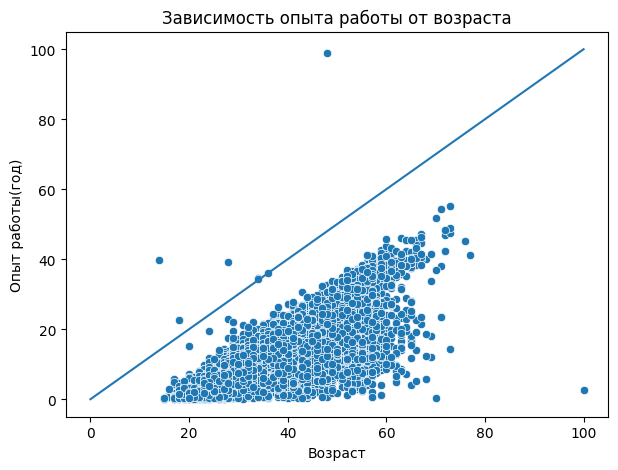

In [26]:
fig = plt.figure(figsize=(7,5))
scatter_data = resume_data.copy()
scatter_data['Опыт работы(год)'] = scatter_data['Опыт работы (месяц)'].apply(lambda x: x / 12)
sns.lineplot(x=[0,100], y=[0,100])
ax = sns.scatterplot(
    data=scatter_data,
    x='Возраст',
    y='Опыт работы(год)'
)
ax.set_title('Зависимость опыта работы от возраста');
print(scatter_data[scatter_data['Опыт работы(год)'] >= scatter_data['Возраст']].shape)

Исходя из полученных данных мы видим, что 7 соскателей имеют опыт работы превышающий возраст, либо равный ему (выбросы).

In [23]:
bar_data = resume_data.groupby(['Город', 'Пол'], as_index=False)['ЗП (руб)'].median()
fig = px.bar(
    bar_data,
    x='ЗП (руб)',
    y='Город',
    barmode='group',
    color='Пол',
    orientation='h',
    title='Медианная заработная плата по городам и полу'
)
fig.show()
fig.write_html("Data/Figure9.html")

Исходя из графика можно наблюдать, что зарплатные ожидания соискателей мужского пола имеют более высокие значения, чем у представителей женского. Признак пола можно также причислить к значимым при прогнозировании заработной платы соискателя.

In [24]:
fig = px.box(
    box_data,
    x='Авто',
    y='ЗП (руб)',
    color='Авто',
    title='Распределение заработной платы в зависимости от наличия автомобиля'
)
fig.show()
fig.write_html("Data/Figure10.html")

По медианному значению, соискатели имеющие автомобиль имеют зарплатные ожидания выше, это может быть связано с тем, что соискателям необходимо нести издержки по содержанию машины, что также можно учитывать при прогнозировании заработной платы соискателя.

# Очистка данных

Начнем с дубликатов в наших данных

In [ ]:
duplicates = resume_data[resume_data.duplicated(subset=resume_data.columns)]
resume_data = resume_data.drop_duplicates()
print(f"Полных копий {duplicates.shape[0]}")

Полных копий 161


Выведите информацию **о числе пропусков** в столбцах. 

In [ ]:
null_data = resume_data.isnull().sum()
display(null_data[null_data > 0])

Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
Опыт работы (месяц)                168
dtype: int64

Поступим следующим образом: удалим строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполним **медианным** значением.

In [ ]:
resume_data = resume_data.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность'])
resume_data['Опыт работы (месяц)'] = resume_data['Опыт работы (месяц)'].fillna(resume_data['Опыт работы (месяц)'].median())
print(f"Средний опыт работы соискателей составил {round(resume_data['Опыт работы (месяц)'].mean())} месяцев")

Средний опыт работы соискателей составил 114 месяцев


Поработаем с выбросами. Сначала очистим данные вручную. Удалим резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [ ]:
outliers = resume_data[(resume_data['ЗП (руб)'] > 1e6) | (resume_data['ЗП (руб)'] < 1e3)]
resume_data = resume_data.drop(outliers.index)
print(f"Выбросов: {outliers.shape[0]} записей")

Выбросов: 89 записей


В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдем такие резюме и удалим их.

In [ ]:
outliers = resume_data[resume_data['Опыт работы (месяц)']/12 >= resume_data['Возраст']]
data = resume_data.drop(outliers.index)
print(f"Количество записей {outliers.shape[0]}")

Количество записей 7


В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуем построить распределение признака в **логарифмическом масштабе**. 

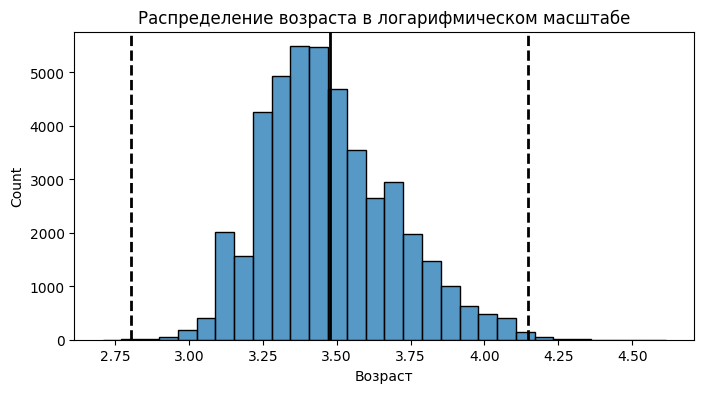

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
hist_data = np.log(resume_data['Возраст'] + 1)
histplot = sns.histplot(hist_data, bins=30, ax=ax)
histplot.axvline(hist_data.mean(), color='k', lw=2)
histplot.axvline(hist_data.mean()+ 3 * hist_data.std(), color='k', ls='--', lw=2)
histplot.axvline(hist_data.mean()- 3 * hist_data.std(), color='k', ls='--', lw=2)
histplot.set_title('Распределение возраста в логарифмическом масштабе');

In [ ]:
def outliers_z_score_mod(data, feature, log_scale=False, left=3, right=3):
    """Функция нахождения выбросов методом z-отклонения

    Args:
        data (DataFrame): Датасет с резюме соискателей
        feature (Series): Столбец датасета в котором необходимо найти выбросы
        log_scale (bool, optional): Использование логарифмического масштаба. Defaults to False.
        left (int, optional): Левая граница. Defaults to 3.
        right (int, optional): Правая граница. Defaults to 3.

    Returns:
        DataFrame: Датасет резюме, определенных как выбросы, Датасет резюме без выбросов
    """
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - left * sigma
    upper_bound = mu + right * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned
outliers, cleaned = outliers_z_score_mod(resume_data, 'Возраст', log_scale=True, left=3, right=4)
display(outliers)
print(f'Число выбросов по методу z-отклонения: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')

,Ищет работу на должность:,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование,Пол,Возраст,Опыт работы (месяц),Город,...,полный день,частичная занятость,сменный график,проектная работа,гибкий график,волонтерство,удаленная работа,стажировка,вахтовый метод,ЗП (руб)
29098,Ведущий инженер-программист,"КБ Аметист, Концерн АГАТ",Ведущий инженер-программист,2019-04-26,Не указано,высшее,М,14,477.0,Москва,...,True,False,False,False,False,False,False,False,False,60000.0
31137,Менеджер по работе с клиентами,"ООО ""ФёрстКэшКомпани""",Менеджер по работе с клиентами,2019-04-06,Не указано,среднее,М,15,2.0,Санкт-Петербург,...,False,True,True,False,True,False,True,False,False,10000.0
32950,Тестировщик игр,OOO ЖМЫХ,Тестировщик ПО,2019-04-09,Не указано,cреднее специальное,М,15,3.0,другие,...,True,False,False,False,False,False,False,False,False,2000.0
33654,Frontend-разработчик,Freelance,Frontend-разработчик,2019-04-19,Не указано,cреднее специальное,М,100,30.0,Санкт-Петербург,...,True,True,False,True,True,False,True,True,False,60000.0


Число выбросов по методу z-отклонения: 4
Результирующее число записей: 44488


Логарифмическое распределение лево ассиметрично. Под категорию выбросов попадают соискатели возрастом 14, 15 и 100 лет.